# Giai đoạn 3: Phân cụm & Đánh giá chất lượng mô hình

Notebook này thực hiện các bước phân cụm thị trường việc làm Việt Nam sử dụng các đặc trưng UMAP 20D thu được từ Giai đoạn 2.

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Cấu hình vẽ đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
%matplotlib inline

## Bước 1: Nạp Dữ liệu và Đặc trưng

Chúng ta sẽ nạp tập dữ liệu sạch cuối cùng từ Phase 2 và các ma trận đặc trưng UMAP (20D phục vụ phân cụm và 2D phục vụ vẽ đồ thị).

In [2]:
df_train = pd.read_csv('../data/clean_data_train_final.csv')
df_test = pd.read_csv('../data/clean_data_test.csv')

train_features = np.load('../data/features_train.npz')
test_features = np.load('../data/features_test.npz')

train_20d = train_features['features_20d']
train_2d = train_features['features_2d']
test_20d = test_features['features_20d']
test_2d = test_features['features_2d']

print(f"Kích thước Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Kích thước đặc trưng 20D Train: {train_20d.shape} | Test: {test_20d.shape}")
print(f"Kích thước đặc trưng 2D Train: {train_2d.shape} | Test: {test_2d.shape}")
df_train.head(10)

Kích thước Train: (353158, 18) | Test: (60644, 17)
Kích thước đặc trưng 20D Train: (353158, 20) | Test: (60644, 20)
Kích thước đặc trưng 2D Train: (353158, 2) | Test: (60644, 2)


,job_title,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,text_combined,word_count,salary_min_m_vnd,salary_max_m_vnd,exp_min_years,exp_max_years,edu_encoded
0,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,12.000.000 - 30.000.000 VND,"Tầng 5, Tòa nhà Phú Hưng 298 Ung Văn Khiêm | 5...",Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,lên kế hoạch tiếp cận chăm sóc khách hàng là c...,thu nhập từ 12 30 triệu lương cứng hoa hồng bá...,độ tuổi từ 27 40 tốt nghiệp cao đẳng đại học c...,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,327,12.0,30.0,6.0,6.0,4.0
1,kỹ sư giám sát xây dựng,10.000.000 - 15.000.000 VND,"68 Song Hành, Quốc lộ 22, Trung Chánh | 72/3C ...",Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,giám sát quản lý các tổ đội từ phần thô đến ho...,mức lương 10 14tr phụ cấp công việc phúc lợi đ...,tốt nghiệp đại học chuyên ngành xây dựng dân d...,kỹ sư giám sát xây dựng tốt nghiệp đại học chu...,247,10.0,15.0,5.0,5.0,5.0
2,tuyển sales telesales cho công ty bhnt prudential,5.000.000 - 7.000.000 VND,"153 Cách Mạng Tháng Tám, Phường Hoa Lư, Thành ...",Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,gọi điện thoại kết nối và lên hẹn với khách hà...,được hưởng đầy đủ chế độ bhxh và nghỉ lễ của n...,cần ứng viên từ 21 tuổi tốt nghiệp thpt trở lên,tuyển sales telesales cho công ty bhnt prudent...,88,5.0,7.0,1.0,1.0,1.0
3,kế toán tổng hợp,8.000.000 - 10.000.000 VND,"159 Nguyễn Chí Thanh | 68 QL1A, Phường An Phú ...",Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,thực hiện hiệu quả sổ sách kế toán các nghiệp ...,lương cơ bản 8 000 000 đồng 10 000 000 đồng th...,trình độ tốt nghiệp cao đẳng đại học chuyên ng...,kế toán tổng hợp trình độ tốt nghiệp cao đẳng ...,306,8.0,10.0,5.0,5.0,4.0
4,tuyển dụng nhân viêv video editor,8.000.000 - 10.000.000 VND,NV 8.1 khu đô thị Green Park - 319 đường Vĩnh ...,Toàn thời gian,Marketing,2 năm,Không,Nhân viên,1 lên chủ đề nội dung 2 biên tập nội dung 3 lê...,mức lương khởi điểm 8 000 000 phụ cấp thưởng k...,tìm kiếm tư liệu video hình ảnh liên quan theo...,tuyển dụng nhân viêv video editor tìm kiếm tư ...,209,8.0,10.0,2.0,2.0,0.0
5,sales online spa,7.000.000 - 16.000.000 VND,236/2 Nguyễn Thái Bình P.12 Q. Tân Bình | 205/...,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,tiếp nhận trả lời các tin nhắn qua facebook fa...,làm việc trong môi trường năng động chuyên ngh...,tối thiểu 1 năm kinh nghiệm ưu tiên kinh nghiệ...,sales online spa tối thiểu 1 năm kinh nghiệm ư...,217,7.0,16.0,3.0,3.0,4.0
6,kế toán nội bộ,7.000.000 - 10.000.000 VND,"117-119 Lý Chính Thắng, Phường 7, Quận 3",Toàn thời gian,Tài chính - Đầu tư - Chứng Khoán,1 năm,Cao đẳng,Chưa cập nhật,kiểm tra thu tiền khách hàng qua ngân hàng int...,mức lương hấp dẫn theo thoả thuận đánh giá đún...,là người hoạt bát nhiệt tình và nhanh nhẹn cẩn...,kế toán nội bộ là người hoạt bát nhiệt tình và...,352,7.0,10.0,1.0,1.0,4.0
7,nhân viên tư vấn qua điện thoại pháp lý,6000000 - 10000000 VND MONTH,Ho Chi Minh City Số 68 đường 3158B Phạm Thế Hi...,Toàn thời gian,Hành chính - Thư ký,Không,Không,Nhân viên,dựa trên danh sách được giao thực hiện các cuộ...,thu nhập cao 9 000 0000 đếm 30 000 000 lương c...,thpt trở lên,nhân viên tư vấn qua điện thoại pháp lý thpt t...,329,6.0,10.0,0.0,0.0,0.0
8,nhân viên tư vấn truyền thông sự kiện,6.000.000 - 15.000.000 VND,"B4-BT2 KĐT MỸ ĐÌNH 2, QUẬN NAM TỪ LIÊM",Toàn thời gian,Bán hàng - Kinh doanh,1 năm,Trung cấp,Nhân viên,tìm kiếm khai thác phát triển hệ thống khách h...,mức lương tương đương năng lực lương cơ bản 5 ...,nam nữ tuổi từ 18 tuổi bằng cấp không quan trọ...,nhân viên tư vấn truyền thông sự kiện nam nữ t...,505,6.0,15.0,1.0,1.0,3.0
9,chuyên viên kinh doanh ô tô lương từ 15 20 triệu,10.000.000 - 15.000.000 VND,"39 Chế Lan Viên, Phường Tây Thạnh, Quận Tân Ph...",Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,sử dụng thành thạo các kỹ năng tìm kiếm khách ...,các đãi ngộ khi bạn gia nhập b

## Bước 2: Khảo sát số cụm tối ưu K

Chúng ta chạy khảo sát thuật toán Mini-Batch K-Means với các giá trị K trong khoảng `[5, 7, 9, 11, 13, 15, 17, 19]`. Đối với chỉ số Silhouette Score, do kích thước tập dữ liệu lớn nên ta lấy mẫu ngẫu nhiên 10,000 dòng để tính toán.

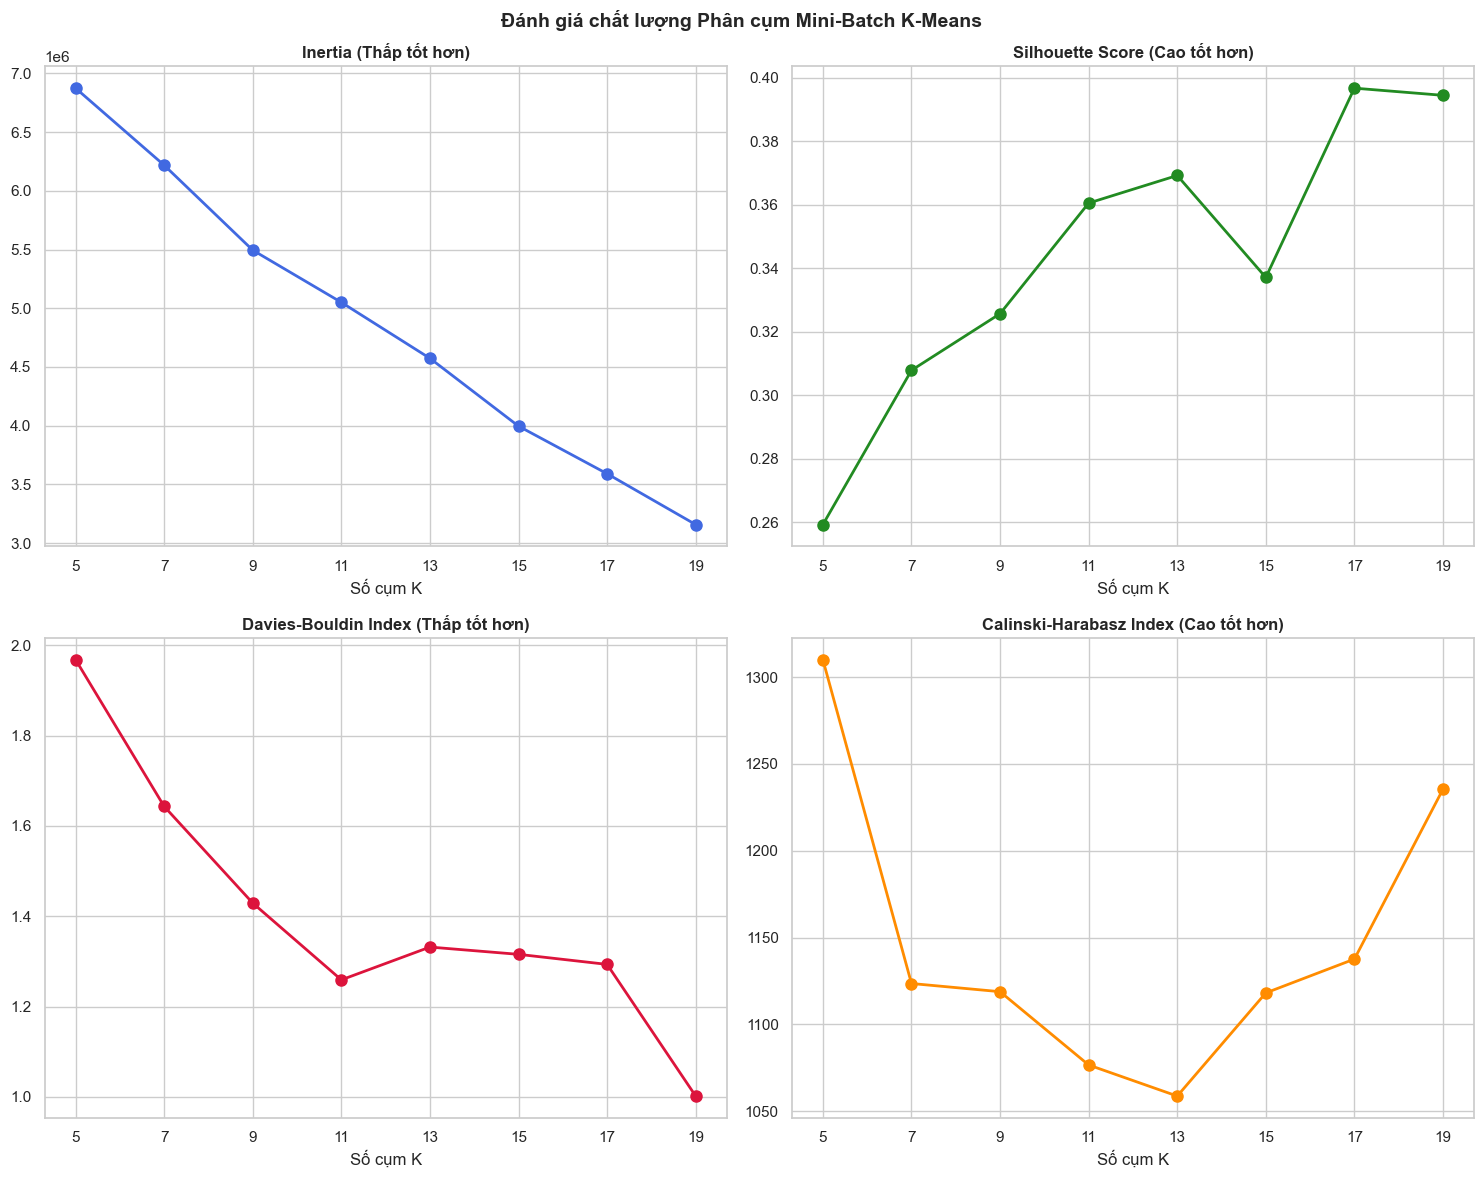

In [3]:
k_list = [5, 7, 9, 11, 13, 15, 17, 19]
sample_size = 10000

np.random.seed(42)
sample_indices = np.random.choice(len(train_20d), sample_size, replace=False)
features_sample = train_20d[sample_indices]

inertias = []
silhouettes = []
dbis = []
chis = []

for k in k_list:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=2048,
        max_no_improvement=10,
        n_init=3
    )
    kmeans.fit(train_20d)
    labels_all = kmeans.labels_
    labels_sample = labels_all[sample_indices]
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_sample, labels_sample, random_state=42))
    dbis.append(davies_bouldin_score(features_sample, labels_sample))
    chis.append(calinski_harabasz_score(features_sample, labels_sample))

# Vẽ biểu đồ
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].plot(k_list, inertias, 'o-', color='royalblue', linewidth=2, markersize=8)
axs[0, 0].set_title('Inertia (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Số cụm K')
axs[0, 0].set_xticks(k_list)

axs[0, 1].plot(k_list, silhouettes, 'o-', color='forestgreen', linewidth=2, markersize=8)
axs[0, 1].set_title('Silhouette Score (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Số cụm K')
axs[0, 1].set_xticks(k_list)

axs[1, 0].plot(k_list, dbis, 'o-', color='crimson', linewidth=2, markersize=8)
axs[1, 0].set_title('Davies-Bouldin Index (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Số cụm K')
axs[1, 0].set_xticks(k_list)

axs[1, 1].plot(k_list, chis, 'o-', color='darkorange', linewidth=2, markersize=8)
axs[1, 1].set_title('Calinski-Harabasz Index (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Số cụm K')
axs[1, 1].set_xticks(k_list)

plt.suptitle('Đánh giá chất lượng Phân cụm Mini-Batch K-Means', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Bước 3: Phân cụm với K tối ưu

Chúng ta chọn `K = 11` làm số cụm tối ưu để huấn luyện mô hình phân cụm cuối cùng, sau đó dự đoán nhãn cụm cho 100% dòng dữ liệu của cả tập huấn luyện (Train) và tập kiểm thử (Test).

In [4]:
k_optimal = 11
kmeans_optimal = MiniBatchKMeans(
    n_clusters=k_optimal,
    random_state=42,
    batch_size=2048,
    max_no_improvement=20,
    n_init=10
)
kmeans_optimal.fit(train_20d)

# Lưu mô hình
joblib.dump(kmeans_optimal, '../models/clustering_model.pkl')

# Dự đoán nhãn cụm
df_train['cluster_id'] = kmeans_optimal.labels_
df_test['cluster_id'] = kmeans_optimal.predict(test_20d)

print(f"Số lượng tin tuyển dụng mỗi cụm trong tập Train:")
print(df_train['cluster_id'].value_counts().sort_index())

Số lượng tin tuyển dụng mỗi cụm trong tập Train:
cluster_id
0      71404
1     148720
2      39078
3      40412
4       5908
5       4780
6       5066
7      12003
8       8034
9       2629
10     15124
Name: count, dtype: int64


## Bước 4: Phân tích Đặc trưng và Gán nhãn cụm tự động

Chúng ta sẽ phân tích phân phối các trường dữ liệu số (Lương, Kinh nghiệm) và các thuộc tính phân loại (Ngành nghề, Địa điểm) trong từng cụm. Đồng thời, sử dụng TF-IDF trích xuất top từ khóa đặc trưng nhất từ mô tả công việc (cột `text_combined`) và tự gán nhãn ngữ nghĩa biểu diễn cho mỗi cụm.

In [5]:
VIETNAMESE_STOP_WORDS = [
    'và', 'của', 'để', 'cho', 'có', 'trong', 'một', 'là', 'các', 'được', 'với', 'những', 'tại', 'này', 
    'theo', 'về', 'ra', 'đã', 'sẽ', 'như', 'khi', 'lên', 'từ', 'nhiều', 'vào', 'hoặc', 'nếu', 'lại', 
    'đang', 'cùng', 'qua', 'trước', 'sau', 'khoảng', 'trên', 'dưới', 'công', 'ty', 'tuyển', 'dụng', 
    'yêu', 'cầu', 'làm', 'việc', 'nhân', 'viên', 'vị', 'trí', 'chúng', 'tôi', 'quyền', 'lợi', 'chế', 
    'độ', 'hồ', 'sơ', 'nộp', 'liên', 'hệ', 'tin', 'tức', 'thông', 'báo', 'mức', 'lương', 'yêu_cầu', 
    'làm_việc', 'nhân_viên', 'công_ty', 'hồ_sơ', 'liên_hệ', 'quyền_lợi', 'chế_độ', 'tuyển_dụng', 
    'đáp', 'ứng', 'công_việc', 'công_tác', 'thực_hiện', 'tham_gia', 'hỗ_trợ', 'phát_triển', 'yêu_cầu_công_việc',
    'báo_cáo', 'quản_lý', 'kỹ_năng', 'khả_năng', 'kinh_nghiệm', 'tốt_nghiệp', 'chuyên_ngành', 'phù_hợp',
    'có_thể', 'được_hưởng', 'được_đóng', 'được_đào_tạo'
]

cluster_profiles = {}
cluster_labels_map = {}

for c in range(k_optimal):
    df_c = df_train[df_train['cluster_id'] == c]
    count_c = len(df_c)
    pct_c = (count_c / len(df_train)) * 100
    
    salary_med = df_c['salary_min_m_vnd'].median()
    exp_med = df_c['exp_min_years'].median()
    
    top_industry = df_c['job_industry'].mode()[0] if not df_c['job_industry'].empty else "Chưa xác định"
    top_location = df_c['location'].mode()[0] if not df_c['location'].empty else "Chưa xác định"
    
    # TF-IDF
    if count_c > 15000:
        texts_c = df_c['text_combined'].sample(n=15000, random_state=42).fillna("").tolist()
    else:
        texts_c = df_c['text_combined'].fillna("").tolist()
        
    vectorizer = TfidfVectorizer(max_features=1000, stop_words=VIETNAMESE_STOP_WORDS, ngram_range=(1, 2))
    try:
        tfidf_matrix = vectorizer.fit_transform(texts_c)
        mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
        feature_names = vectorizer.get_feature_names_out()
        top_indices = mean_tfidf.argsort()[::-1][:5]
        keywords = [feature_names[i] for i in top_indices]
    except:
        keywords = ["n/a"]
        
    # Gán nhãn ngữ nghĩa tự động
    salary_tier = "Lương Cao" if salary_med >= 15.0 else ("Lương Trung Bình" if salary_med >= 8.0 else "Lương Thấp/Chưa Rõ")
    ind_short = top_industry.split('/')[0].strip() if '/' in top_industry else top_industry
    keywords_viz = ", ".join([kw.replace('_', ' ') for kw in keywords[:3]])
    
    semantic_label = f"Cụm {c:02d}: {ind_short} ({salary_tier} - ~{salary_med:.1f}M) - Key: {keywords_viz}"
    cluster_labels_map[c] = semantic_label
    
    cluster_profiles[c] = {
        'percent': pct_c,
        'salary_med': salary_med,
        'exp_med': exp_med,
        'top_industry': top_industry,
        'top_location': top_location,
        'keywords': keywords,
        'label': semantic_label
    }

df_train['cluster_label'] = df_train['cluster_id'].map(cluster_labels_map)
df_test['cluster_label'] = df_test['cluster_id'].map(cluster_labels_map)

# Hiển thị bảng tổng hợp
summary_data = []
for c in range(k_optimal):
    p = cluster_profiles[c]
    summary_data.append({
        'Cụm': c,
        'Tỷ lệ': f"{p['percent']:.2f}%",
        'Lương Trung vị': f"{p['salary_med']:.1f}M",
        'Kinh nghiệm Trung vị': f"{p['exp_med']:.1f} năm",
        'Ngành chính': p['top_industry'],
        'Tỉnh thành chính': p['top_location'],
        'Từ khóa chủ đạo': ", ".join(p['keywords'][:5])
    })
df_summary = pd.DataFrame(summary_data)
display(df_summary)

print("\n10 dòng đầu của dữ liệu huấn luyện sau khi phân cụm:")
display(df_train[['job_title', 'salary', 'location', 'job_industry', 'cluster_id', 'cluster_label']].head(10))

,Cụm,Tỷ lệ,Lương Trung vị,Kinh nghiệm Trung vị,Ngành chính,Tỉnh thành chính,Từ khóa chủ đạo
0,0,20.22%,10.0M,3.0 năm,Xây dựng,"340E-340F Hoàng Văn Thụ, Phường 04 | 52 Thống ...","hàng, năng, điện, thiết, kỹ"
1,1,42.11%,8.0M,2.0 năm,Bán hàng - Kinh doanh,"Tầng 8, tầng 9, tầng 10 tòa nhà số 24C đường P...","hàng, khách, khách hàng, năng, kinh"
2,2,11.07%,9.0M,3.0 năm,Kế toán / Kiểm toán,198 Hoàng Văn Thụ Phường 9 Phú Nhuận,"toán, kế, kế toán, hàng, định"
3,3,11.44%,10.0M,3.0 năm,Giáo dục - Đào tạo / Biên phiên dịch,Hà Nội,"năng, hàng, marketing, động, kinh"
4,4,1.67%,7.0M,2.0 năm,Dệt may - Da giày - Thời trang,"Số 47, Đường 17, Khu phố 3, Phường Hiệp Bình P...","hàng, năng, khách, khách hàng, thực"
5,5,1.35%,7.0M,3.0 năm,Khách sạn - Nhà hàng - Du lịch,"Tòa nhà Mường Thanh, Lô CC5, bán đảo Linh Đàm,...","hàng, khách, năng, lý, nhà"
6,6,1.43%,9.0M,2.0 năm,Thu mua - Kho Vận - Chuỗi cung ứng,"15, Lê Thánh Tôn, Phường Bến Nghé, Quận 1","hàng, kho, năng, lý, quản"
7,7,3.40%,9.0M,3.0 năm,Vận Tải - Lái xe - Giao nhận,"15, Lê Thánh Tôn, Phường Bến Nghé, Quận 1","hàng, xe, năng, khách, khách hàng"
8,8,2.27%,10.0M,3.0 năm,Thực phẩm - Đồ uống / Công nghệ thực phẩm - Di...,"Tòa nhà Orbital, Khu công viên phần mềm Quang ...","hàng, sản, năng, phẩm, khách"
9,9,0.74%,10.0M,3.0 năm,IT Phần mềm,..... | 198 Hoàng Văn Thụ Phường 9 Phú Nhuận,"năng, and, thống, phần, kinh"



10 dòng đầu của dữ liệu huấn luyện sau khi phân cụm:


,job_title,salary,location,job_industry,cluster_id,cluster_label
0,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,12.000.000 - 30.000.000 VND,"Tầng 5, Tòa nhà Phú Hưng 298 Ung Văn Khiêm | 5...",Xây dựng,0,Cụm 00: Xây dựng (Lương Trung Bình - ~10.0M) -...
1,kỹ sư giám sát xây dựng,10.000.000 - 15.000.000 VND,"68 Song Hành, Quốc lộ 22, Trung Chánh | 72/3C ...",Xây dựng,0,Cụm 00: Xây dựng (Lương Trung Bình - ~10.0M) -...
2,tuyển sales telesales cho công ty bhnt prudential,5.000.000 - 7.000.000 VND,"153 Cách Mạng Tháng Tám, Phường Hoa Lư, Thành ...",Chưa xác định,1,Cụm 01: Bán hàng - Kinh doanh (Lương Trung Bìn...
3,kế toán tổng hợp,8.000.000 - 10.000.000 VND,"159 Nguyễn Chí Thanh | 68 QL1A, Phường An Phú ...",Kế toán / Kiểm toán,2,Cụm 02: Kế toán (Lương Trung Bình - ~9.0M) - K...
4,tuyển dụng nhân viêv video editor,8.000.000 - 10.000.000 VND,NV 8.1 khu đô thị Green Park - 319 đường Vĩnh ...,Marketing,3,Cụm 03: Giáo dục - Đào tạo (Lương Trung Bình -...
5,sales online spa,7.000.000 - 16.000.000 VND,236/2 Nguyễn Thái Bình P.12 Q. Tân Bình | 205/...,Chăm sóc khách hàng,1,Cụm 01: Bán hàng - Kinh doanh (Lương Trung Bìn...
6,kế toán nội bộ,7.000.000 - 10.000.000 VND,"117-119 Lý Chính Thắng, Phường 7, Quận 3",Tài chính - Đầu tư - Chứng Khoán,2,Cụm 02: Kế toán (Lương Trung Bình - ~9.0M) - K...
7,nhân viên tư vấn qua điện thoại pháp lý,6000000 - 10000000 VND MONTH,Ho Chi Minh City Số 68 đường 3158B Phạm Thế Hi...,Hành chính - Thư ký,1,Cụm 01: Bán hàng - Kinh doanh (Lương Trung Bìn...
8,nhân viên tư vấn truyền thông sự kiện,6.000.000 - 15.000.000 VND,"B4-BT2 KĐT MỸ ĐÌNH 2, QUẬN NAM TỪ LIÊM",Bán hàng - Kinh doanh,3,Cụm 03: Giáo dục - Đào tạo (Lương Trung Bình -...
9,chuyên viên kinh doanh ô tô lương từ 15 20 triệu,10.000.000 - 15.000.000 VND,"39 Chế Lan Viên, Phường Tây Thạnh, Quận Tân Ph...",Chăm sóc khách hàng,1,Cụm 01: Bán hàng - Kinh doanh (Lương Trung Bìn...


## Bước 5: Trực quan hóa các Cụm trên không gian UMAP 2D

Chúng ta vẽ biểu đồ phân tán UMAP 2D của tập dữ liệu Train với nhãn màu tương ứng của các cụm đã gán. Sử dụng kích thước điểm và độ mờ tối ưu (`s=3`, `alpha=0.35`, `edgecolors='none'`) để tránh hiện tượng chồng lấp điểm dữ liệu (overplotting).

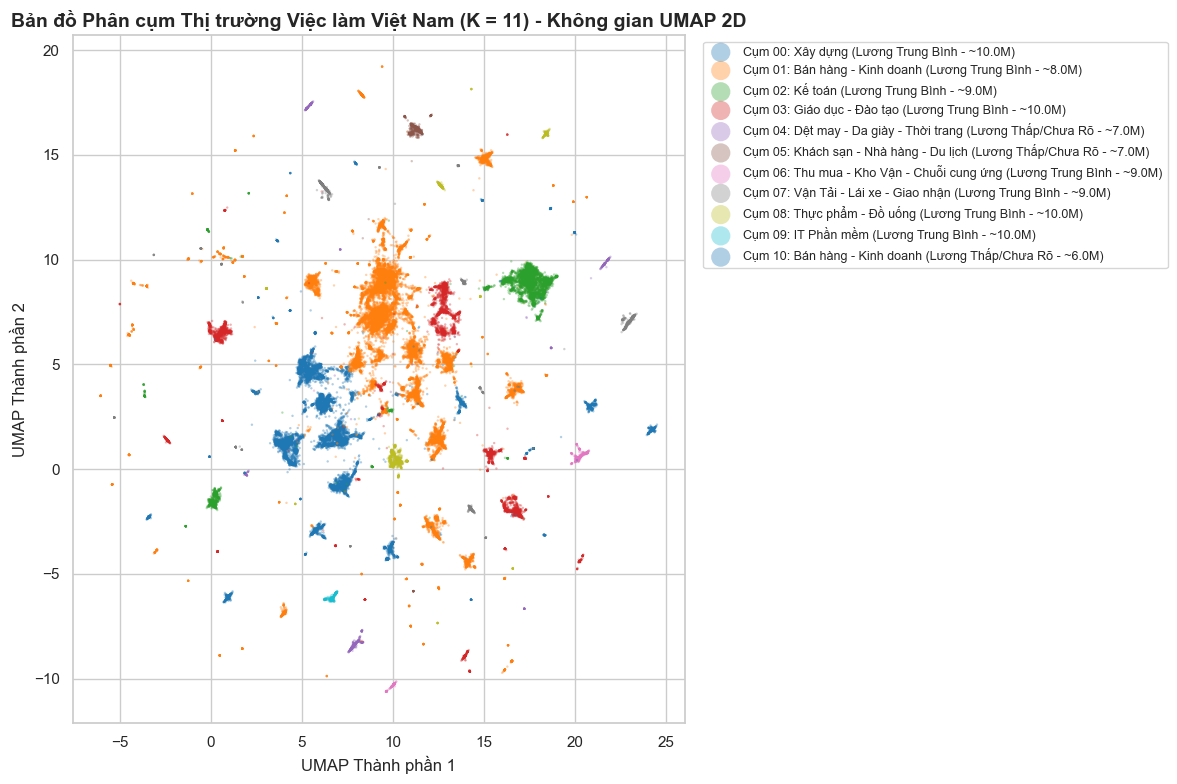

In [6]:
plt.figure(figsize=(12, 8))
plot_sample = min(50000, len(train_2d)) # Tăng cỡ mẫu vẽ biểu đồ lên 50,000 điểm
np.random.seed(42)
indices = np.random.choice(len(train_2d), plot_sample, replace=False)

palette = sns.color_palette("tab10", n_colors=k_optimal)

for c in range(k_optimal):
    cluster_mask = df_train.iloc[indices]['cluster_id'] == c
    label_text = cluster_labels_map[c]
    short_label = label_text.split(" - Key:")[0]
    
    plt.scatter(
        train_2d[indices][cluster_mask, 0],
        train_2d[indices][cluster_mask, 1],
        s=3,
        alpha=0.35,
        color=palette[c],
        label=short_label,
        edgecolors='none'
    )

plt.title('Bản đồ Phân cụm Thị trường Việc làm Việt Nam (K = 11) - Không gian UMAP 2D', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Thành phần 1')
plt.ylabel('UMAP Thành phần 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=8, fontsize=9)
plt.tight_layout()
plt.show()

### Nhận xét chuyên môn về Cấu trúc Không gian Đặc trưng & Mức lương

Quan sát cực kỳ quan trọng từ biểu đồ phân bố 2D UMAP tô màu theo cụm và mức lương (ở Phase 2):

*   **Sự phân tách rõ rệt của các cụm**: Không gian đặc trưng UMAP 2D biểu diễn các cụm cục bộ khá tách biệt và tập trung tốt, cho thấy thuật toán Mini-Batch K-Means đã gom cụm dữ liệu dựa trên các cấu trúc đặc trưng ẩn có nghĩa (chủ yếu dựa trên mô tả văn bản công việc và ngành nghề).
*   **Sự phân bố chéo của mức lương**: Mức lương không tạo ra một sự phân tách ranh giới rõ ràng (màu sắc mức lương bị trộn lẫn nhiều giữa các cụm). Điều này chứng minh rằng **cấu trúc không gian đặc trưng (Embedding Structure) không trùng khớp hoàn toàn với cấu trúc mức lương (Salary Structure)**. 
*   **Lý giải thực tế**: Điều này hoàn toàn hợp lý trong thị trường lao động thực tế. Lương của một công việc không phải là đặc trưng quyết định thể loại công việc đó. Cùng một ngành nghề (ví dụ: CNTT) hoặc cùng một vị trí có thể có dải lương rất rộng, phụ thuộc vào nhiều yếu tố hỗn hợp không đồng nhất khác như: số năm kinh nghiệm, địa điểm làm việc (Hà Nội, TP.HCM có mức lương trung bình khác biệt), quy mô công ty, kỹ năng chuyên môn sâu, hoặc tính chất công việc (on-site/remote). Do đó, UMAP và mô hình phân cụm không tự động chia cắt dữ liệu chỉ theo biến số lương.
*   **Nhận xét chuyên môn (Academic Observation)**: 
  > *The UMAP projection reveals several meaningful local clusters, indicating that the high-dimensional feature space contains latent subgroup structures. However, salary levels remain distributed across multiple clusters, suggesting that salary is influenced by heterogeneous factors rather than serving as the dominant clustering attribute.*

## Bước 6: Lưu kết quả phân cụm

Chúng ta lưu lại các tập dữ liệu Train và Test đã gán nhãn ra file CSV để phục vụ phân tích hoặc sử dụng sau này.

In [7]:
df_train.to_csv('../data/clean_data_train_clustered.csv', index=False)
df_test.to_csv('../data/clean_data_test_clustered.csv', index=False)
print("Đã lưu các file dữ liệu phân cụm thành công!")

Đã lưu các file dữ liệu phân cụm thành công!
